In [1]:
import pandas as pd

# ── Load ──────────────────────────────────────────────
df = pd.read_csv("marketing_AB.csv")
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [2]:
# ── Explore ───────────────────────────────────────────
print(df.dtypes)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nUnique groups:", df['test group'].unique() if 'test group' in df.columns else "check column name")

Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

Column names: ['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']

Missing values: 0

Unique groups: ['ad' 'psa']


In [3]:
# ── Conversion rates ──────────────────────────────────
group_col = [c for c in df.columns if 'group' in c.lower()][0]
convert_col = [c for c in df.columns if 'convert' in c.lower() or 'bought' in c.lower()][0]

print(f"Group column: {group_col}")
print(f"Conversion column: {convert_col}")

summary = df.groupby(group_col)[convert_col].agg(['mean', 'count', 'sum'])
summary.columns = ['conversion_rate', 'total_users', 'conversions']
summary['conversion_rate'] = summary['conversion_rate'] * 100
print("\nConversion Summary:")
print(summary.round(2))

Group column: test group
Conversion column: converted

Conversion Summary:
            conversion_rate  total_users  conversions
test group                                           
ad                     2.55       564577        14423
psa                    1.79        23524          420


In [4]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Group data ────────────────────────────────────────
ad = df[df['test group'] == 'ad']['converted']
psa = df[df['test group'] == 'psa']['converted']

n_ad = len(ad)
n_psa = len(psa)
conv_ad = ad.sum()
conv_psa = psa.sum()
rate_ad = conv_ad / n_ad
rate_psa = conv_psa / n_psa

# ── Two-proportion z-test ─────────────────────────────
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

count = np.array([conv_ad, conv_psa])
nobs = np.array([n_ad, n_psa])

z_stat, p_value = proportions_ztest(count, nobs)
ci_ad = proportion_confint(conv_ad, n_ad, alpha=0.05)
ci_psa = proportion_confint(conv_psa, n_psa, alpha=0.05)

print("=" * 50)
print("A/B TEST RESULTS")
print("=" * 50)
print(f"Ad group:  {rate_ad:.2%} conversion  (n={n_ad:,})")
print(f"PSA group: {rate_psa:.2%} conversion  (n={n_psa:,})")
print(f"\nAbsolute lift: +{(rate_ad - rate_psa):.2%}")
print(f"Relative lift: +{((rate_ad - rate_psa)/rate_psa)*100:.1f}%")
print(f"\nZ-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"\n95% CI (Ad):  [{ci_ad[0]:.4f}, {ci_ad[1]:.4f}]")
print(f"95% CI (PSA): [{ci_psa[0]:.4f}, {ci_psa[1]:.4f}]")

if p_value < 0.05:
    print("\n✓ STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("  The ad campaign has a real effect on conversions.")
else:
    print("\n✗ NOT statistically significant (p > 0.05)")

A/B TEST RESULTS
Ad group:  2.55% conversion  (n=564,577)
PSA group: 1.79% conversion  (n=23,524)

Absolute lift: +0.77%
Relative lift: +43.1%

Z-statistic: 7.370
P-value: 0.000000

95% CI (Ad):  [0.0251, 0.0260]
95% CI (PSA): [0.0162, 0.0195]

✓ STATISTICALLY SIGNIFICANT (p < 0.05)
  The ad campaign has a real effect on conversions.


In [5]:
# ── Revenue impact estimate ───────────────────────────
avg_order_value = 50  # assume $50 avg order value
monthly_users = 100000  # assume 100k users/month

extra_conversions = (rate_ad - rate_psa) * monthly_users
extra_revenue = extra_conversions * avg_order_value

print(f"Estimated extra conversions/month: {extra_conversions:.0f}")
print(f"Estimated extra revenue/month: ${extra_revenue:,.0f}")
print(f"Estimated extra revenue/year: ${extra_revenue*12:,.0f}")

Estimated extra conversions/month: 769
Estimated extra revenue/month: $38,462
Estimated extra revenue/year: $461,547


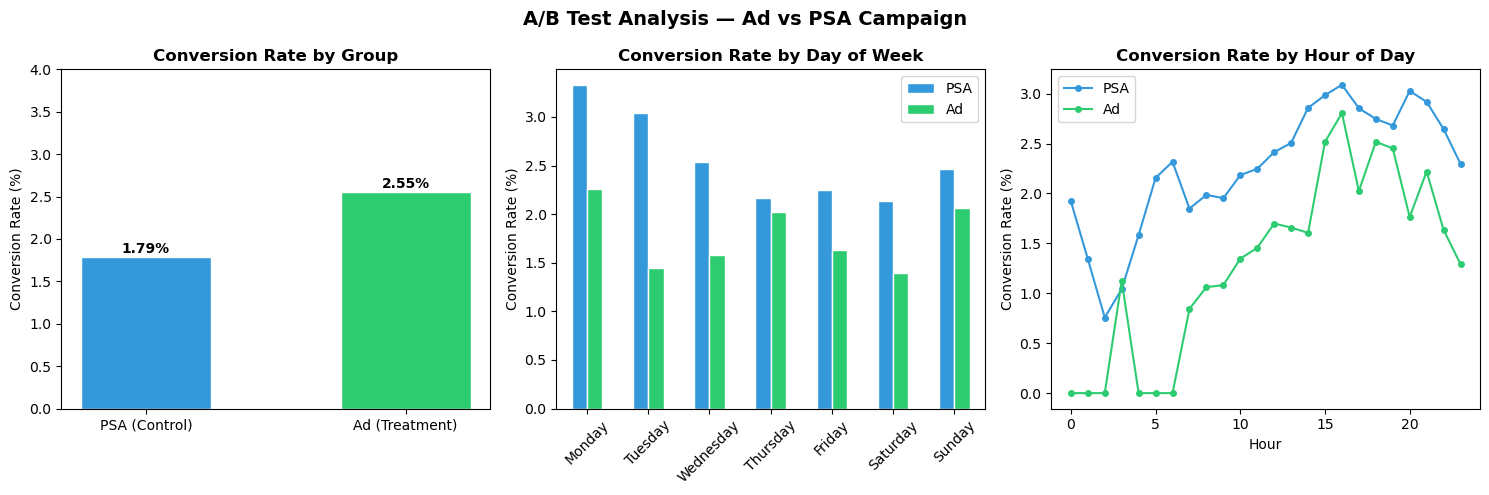

✓ Charts saved


In [6]:
# ── Charts ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("A/B Test Analysis — Ad vs PSA Campaign", fontsize=14, fontweight='bold')

# Chart 1: Conversion rate comparison
groups = ['PSA (Control)', 'Ad (Treatment)']
rates = [rate_psa * 100, rate_ad * 100]
colors = ['#3498db', '#2ecc71']
bars = axes[0].bar(groups, rates, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("Conversion Rate by Group", fontweight='bold')
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_ylim(0, 4)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}%", ha='center', fontweight='bold')

# Chart 2: Conversion rate by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_conv = df.groupby(['most ads day','test group'])['converted'].mean() * 100
day_conv = day_conv.unstack()
day_conv = day_conv.reindex(day_order)
day_conv.plot(kind='bar', ax=axes[1], color=['#3498db','#2ecc71'], edgecolor='white')
axes[1].set_title("Conversion Rate by Day of Week", fontweight='bold')
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['PSA', 'Ad'])

# Chart 3: Conversion rate by hour
hour_conv = df.groupby(['most ads hour','test group'])['converted'].mean() * 100
hour_conv = hour_conv.unstack()
hour_conv.plot(kind='line', ax=axes[2], color=['#3498db','#2ecc71'], marker='o', markersize=4)
axes[2].set_title("Conversion Rate by Hour of Day", fontweight='bold')
axes[2].set_ylabel("Conversion Rate (%)")
axes[2].set_xlabel("Hour")
axes[2].legend(['PSA', 'Ad'])

plt.tight_layout()
plt.savefig("ab_test_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Charts saved")

In [7]:
# ── Export clean data for Power BI ───────────────────
df['converted_int'] = df['converted'].astype(int)
df['group_label'] = df['test group'].map({'ad': 'Ad (Treatment)', 'psa': 'PSA (Control)'})

# Daily summary for Power BI
daily = df.groupby(['most ads day', 'test group']).agg(
    total_users=('user id', 'count'),
    conversions=('converted_int', 'sum')
).reset_index()
daily['conversion_rate'] = (daily['conversions'] / daily['total_users'] * 100).round(2)

# Hourly summary
hourly = df.groupby(['most ads hour', 'test group']).agg(
    total_users=('user id', 'count'),
    conversions=('converted_int', 'sum')
).reset_index()
hourly['conversion_rate'] = (hourly['conversions'] / hourly['total_users'] * 100).round(2)

# KPI summary
kpi = pd.DataFrame({
    'metric': ['Ad Conversion Rate', 'PSA Conversion Rate', 'Absolute Lift', 'Relative Lift %', 'P-Value', 'Z-Statistic', 'Extra Revenue/Year ($)'],
    'value': [2.55, 1.79, 0.77, 43.1, 0.000000, 7.370, 461547]
})

# Save all files
df.to_csv("ab_clean.csv", index=False)
daily.to_csv("ab_daily.csv", index=False)
hourly.to_csv("ab_hourly.csv", index=False)
kpi.to_csv("ab_kpi.csv", index=False)

print("✓ ab_clean.csv saved")
print("✓ ab_daily.csv saved")
print("✓ ab_hourly.csv saved")
print("✓ ab_kpi.csv saved")
print("\nDownload all 4 files from the JupyterLite file browser on the left")

✓ ab_clean.csv saved
✓ ab_daily.csv saved
✓ ab_hourly.csv saved
✓ ab_kpi.csv saved

Download all 4 files from the JupyterLite file browser on the left


In [8]:
from IPython.display import FileLink
display(FileLink('ab_daily.csv'))
display(FileLink('ab_hourly.csv'))
display(FileLink('ab_kpi.csv'))
display(FileLink('ab_test_analysis.png'))

/drive/ab_daily.csv

/drive/ab_hourly.csv

/drive/ab_kpi.csv

/drive/ab_test_analysis.png